Loading data...
Loaded predictions for 304 participants
Loaded ground truth for 334 participants
Calculating daily accuracy...


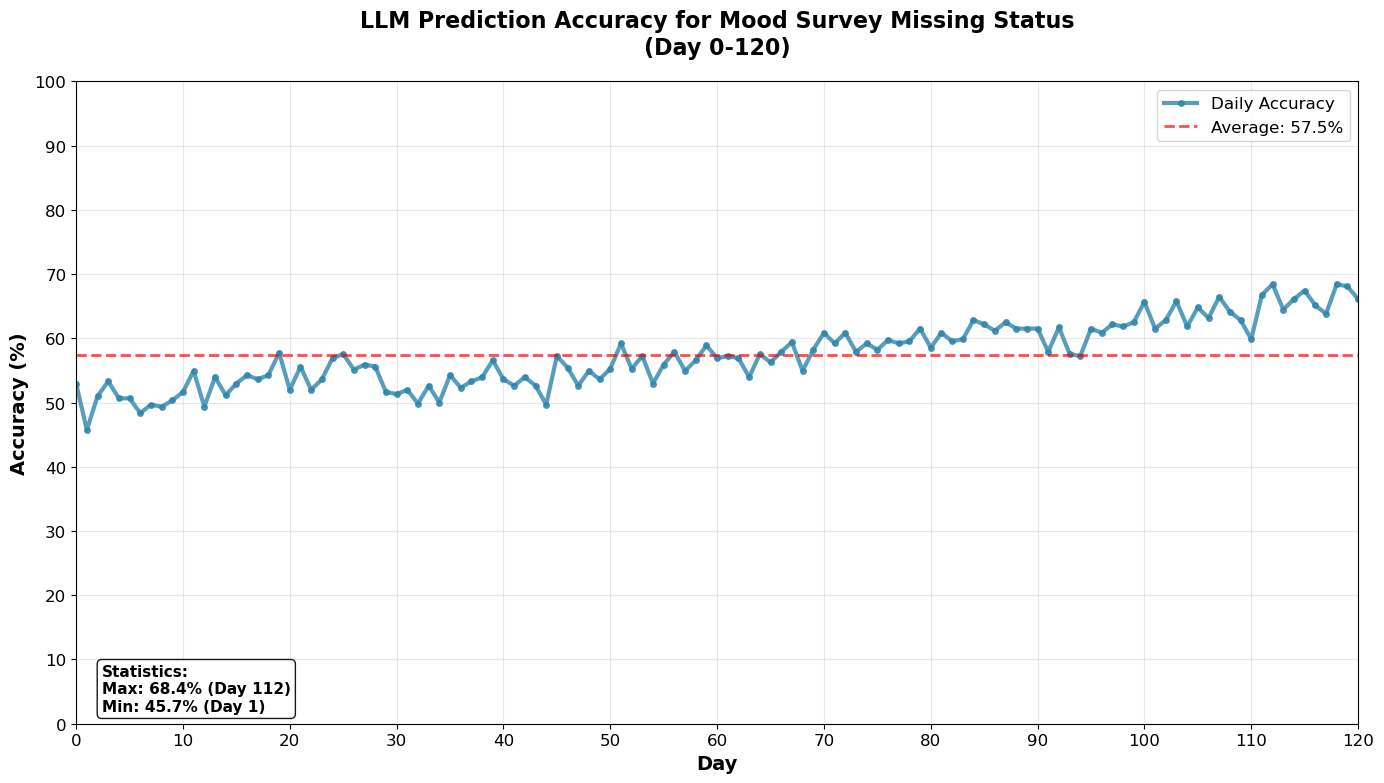


ACCURACY SUMMARY STATISTICS
Overall Average Accuracy: 57.46%
Maximum Accuracy: 68.42% (Day 112)
Minimum Accuracy: 45.72% (Day 1)
Total Predictions Analyzed: 36,773

Accuracy for Selected Days:
------------------------------
Day   0:  53.0% (161/304 correct)
Day  20:  52.0% (158/304 correct)
Day  40:  53.6% (163/304 correct)
Day  60:  56.9% (173/304 correct)
Day  80:  58.6% (178/304 correct)
Day 100:  65.7% (199/303 correct)
Day 120:  66.1% (201/304 correct)


In [6]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Set style for better visualization
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

def load_predictions(trajectory_dir: Path):
    """Load all predictions from traj_0 directory"""
    predictions_data = {}
    
    for participant_dir in trajectory_dir.iterdir():
        if participant_dir.is_dir():
            participant_id = participant_dir.name
            predictions_file = participant_dir / "predictions.json"
            
            if predictions_file.exists():
                with open(predictions_file, 'r', encoding='utf-8') as f:
                    predictions_data[participant_id] = json.load(f)
    
    return predictions_data

def load_ground_truth():
    """Load ground truth data from participants_data.json"""
    with open("participants_data.json", 'r', encoding='utf-8') as f:
        return json.load(f)

def calculate_daily_accuracy(predictions_data, ground_truth_data):
    """Calculate daily accuracy for missing prediction from day 0 to 120"""
    daily_accuracy = []
    
    for day in range(0, 121):
        correct_predictions = 0
        total_predictions = 0
        
        for participant_id, predictions in predictions_data.items():
            if participant_id not in ground_truth_data:
                continue
                
            # Get ground truth mood data
            gt_mood_data = ground_truth_data[participant_id].get("Mood", {})
            
            # Find prediction for this day
            prediction = next((p for p in predictions if p.get("day") == day), None)
            
            if prediction and "model_response_parsed" in prediction:
                parsed = prediction["model_response_parsed"]
                
                # Skip if parsed is None
                if parsed is None:
                    continue
                    
                mood_completion = parsed.get("mood_completion", "missing")
                
                # Determine ground truth missing status
                day_key = f"Day {day}"
                is_missing_gt = day_key not in gt_mood_data
                
                # Determine LLM prediction missing status
                is_missing_llm = mood_completion == "missing"
                
                # Check if prediction is correct
                if is_missing_llm == is_missing_gt:
                    correct_predictions += 1
                
                total_predictions += 1
        
        # Calculate accuracy
        accuracy = (correct_predictions / total_predictions * 100) if total_predictions > 0 else 0
        
        daily_accuracy.append({
            'day': day,
            'accuracy': accuracy,
            'correct_predictions': correct_predictions,
            'total_predictions': total_predictions
        })
    
    return pd.DataFrame(daily_accuracy)

# Main execution
try:
    print("Loading data...")
    trajectory_dir = Path("traj_0")
    predictions_data = load_predictions(trajectory_dir)
    ground_truth_data = load_ground_truth()

    print(f"Loaded predictions for {len(predictions_data)} participants")
    print(f"Loaded ground truth for {len(ground_truth_data)} participants")

    # Calculate daily accuracy
    print("Calculating daily accuracy...")
    accuracy_df = calculate_daily_accuracy(predictions_data, ground_truth_data)

    # Create the plot
    plt.figure(figsize=(14, 8))

    # Plot accuracy trend line
    plt.plot(accuracy_df['day'], accuracy_df['accuracy'], 
             linewidth=3, marker='o', markersize=4, 
             color='#2E86AB', alpha=0.8, label='Daily Accuracy')

    # Add average accuracy line
    avg_accuracy = accuracy_df['accuracy'].mean()
    plt.axhline(y=avg_accuracy, color='red', linestyle='--', linewidth=2, 
                alpha=0.7, label=f'Average: {avg_accuracy:.1f}%')

    # Customize the plot
    plt.title('LLM Prediction Accuracy for Mood Survey Missing Status\n(Day 0-120)', 
              fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Day', fontsize=14, fontweight='bold')
    plt.ylabel('Accuracy (%)', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)

    # Set axis limits and ticks
    plt.xlim(0, 120)
    plt.ylim(0, 100)
    plt.xticks(range(0, 121, 10))
    plt.yticks(range(0, 101, 10))

    # Add legend
    plt.legend(loc='upper right', fontsize=12)

    # Add some statistics as text
    max_acc = accuracy_df['accuracy'].max()
    min_acc = accuracy_df['accuracy'].min()
    max_day = accuracy_df.loc[accuracy_df['accuracy'].idxmax(), 'day']
    min_day = accuracy_df.loc[accuracy_df['accuracy'].idxmin(), 'day']

    stats_text = f'Statistics:\nMax: {max_acc:.1f}% (Day {max_day})\nMin: {min_acc:.1f}% (Day {min_day})'
    plt.annotate(stats_text, xy=(0.02, 0.02), xycoords='axes fraction',
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.9),
                fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.show()

    # Print summary statistics
    print("\n" + "="*60)
    print("ACCURACY SUMMARY STATISTICS")
    print("="*60)
    print(f"Overall Average Accuracy: {avg_accuracy:.2f}%")
    print(f"Maximum Accuracy: {max_acc:.2f}% (Day {max_day})")
    print(f"Minimum Accuracy: {min_acc:.2f}% (Day {min_day})")
    print(f"Total Predictions Analyzed: {accuracy_df['total_predictions'].sum():,}")

    # Print accuracy for key days
    print("\nAccuracy for Selected Days:")
    print("-" * 30)
    key_days = [0, 20, 40, 60, 80, 100, 120]
    for day in key_days:
        day_data = accuracy_df[accuracy_df['day'] == day]
        if len(day_data) > 0:
            accuracy = day_data['accuracy'].values[0]
            total = day_data['total_predictions'].values[0]
            correct = day_data['correct_predictions'].values[0]
            print(f"Day {day:3d}: {accuracy:5.1f}% ({correct:3d}/{total:3d} correct)")

except Exception as e:
    print(f"Error in main execution: {e}")
    import traceback
    traceback.print_exc()

Loading data...
Loaded predictions for 304 participants
Loaded ground truth for 334 participants

Calculating daily accuracy by demographic groups...

Demographic Groups Found:
------------------------------
arm: ['Intervention', 'Control']
gender: ['Male', 'Female']
transplant_type: ['Allogeneic', 'Autologous']
role: ['Patients', 'Caregivers']

Generating plots...


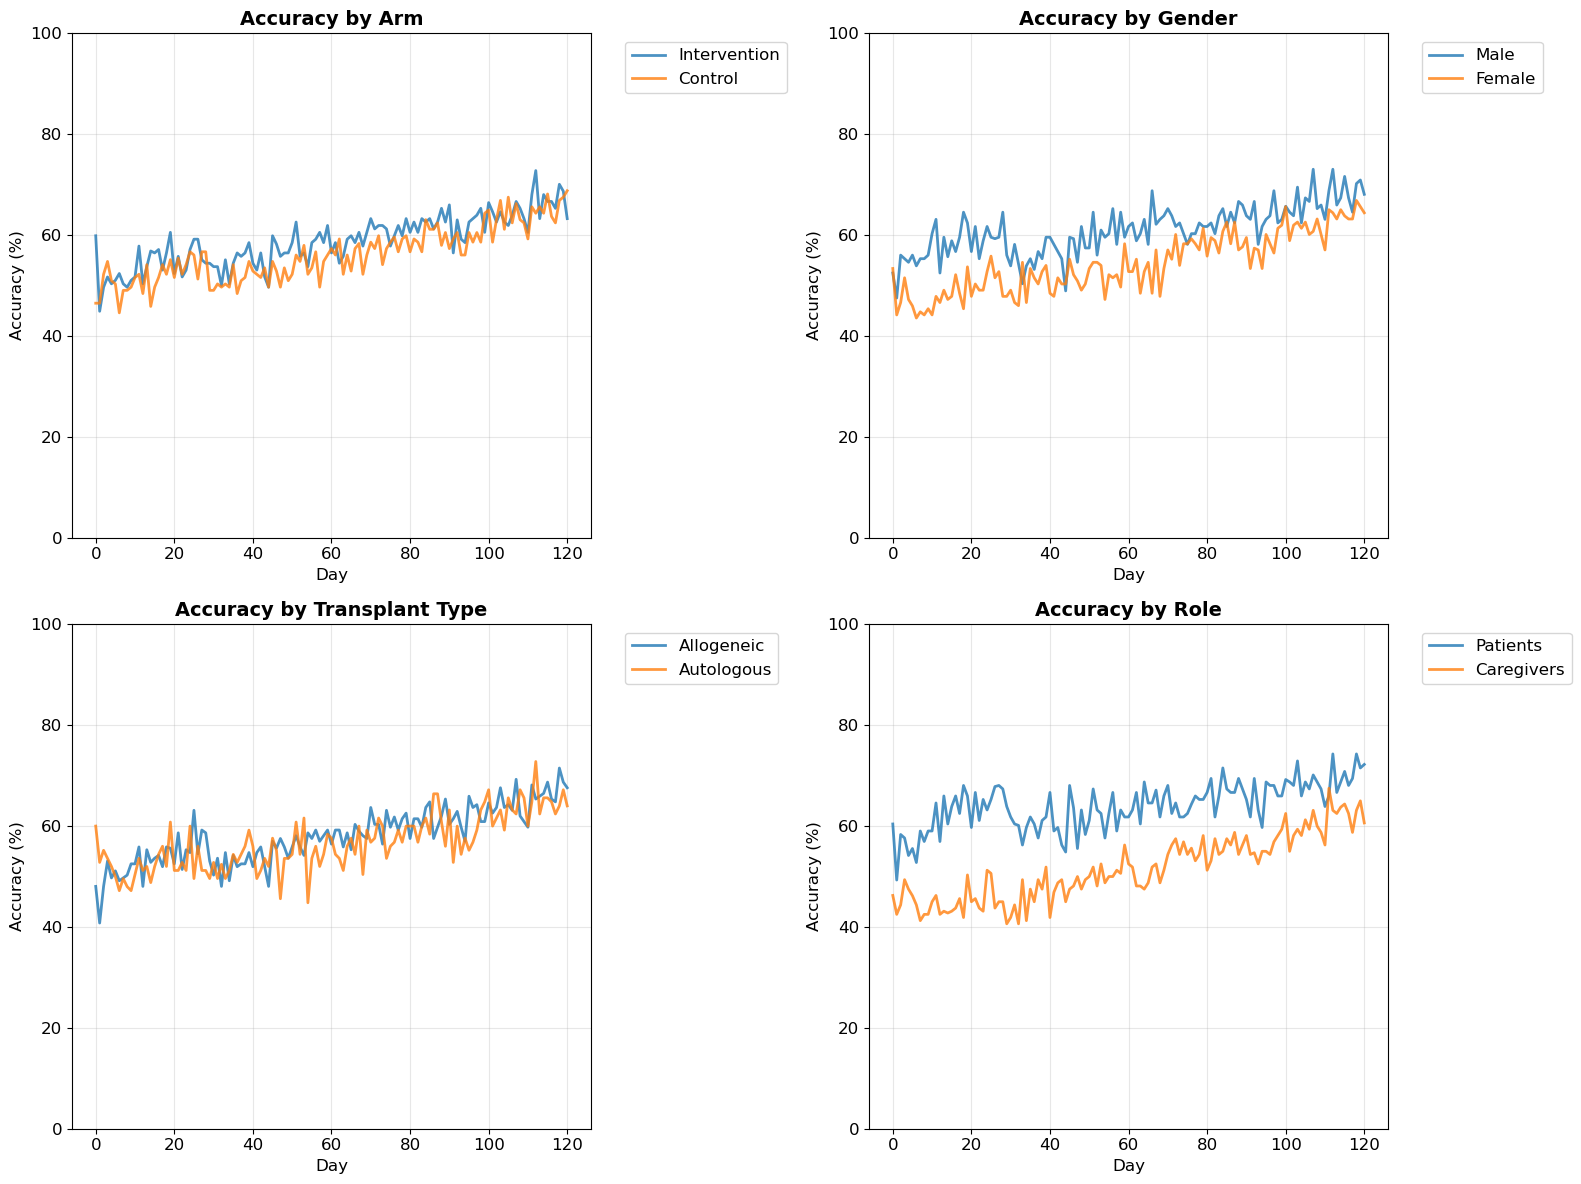

DEMOGRAPHIC ACCURACY SUMMARY

ARM ANALYSIS:
--------------------------------------------------
  Intervention:
    Average: 58.8% ± 5.2%
    Range: 44.9% - 72.8%
    Total predictions: 17,780

  Control:
    Average: 56.2% ± 5.5%
    Range: 44.6% - 68.8%
    Total predictions: 18,993


GENDER ANALYSIS:
--------------------------------------------------
  Male:
    Average: 61.0% ± 5.0%
    Range: 47.5% - 73.0%
    Total predictions: 17,055

  Female:
    Average: 54.4% ± 6.0%
    Range: 43.6% - 66.9%
    Total predictions: 19,718


TRANSPLANT_TYPE ANALYSIS:
--------------------------------------------------
  Allogeneic:
    Average: 58.0% ± 5.6%
    Range: 40.8% - 71.5%
    Total predictions: 21,650

  Autologous:
    Average: 56.7% ± 5.5%
    Range: 44.8% - 72.8%
    Total predictions: 15,123


ROLE ANALYSIS:
--------------------------------------------------
  Patients:
    Average: 64.0% ± 4.7%
    Range: 49.3% - 74.3%
    Total predictions: 17,418

  Caregivers:
    Average: 51.6%

In [8]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from typing import Dict, List, Tuple

def load_predictions(trajectory_dir: Path) -> Dict[str, List[Dict]]:
    """
    Load all predictions from traj_0 directory
    """
    predictions_data = {}
    
    for participant_dir in trajectory_dir.iterdir():
        if participant_dir.is_dir():
            participant_id = participant_dir.name
            predictions_file = participant_dir / "predictions.json"
            
            if predictions_file.exists():
                with open(predictions_file, 'r', encoding='utf-8') as f:
                    predictions_data[participant_id] = json.load(f)
    
    return predictions_data

def load_ground_truth() -> Dict[str, Dict]:
    """
    Load ground truth data from participants_data.json
    """
    with open("participants_data.json", 'r', encoding='utf-8') as f:
        return json.load(f)

def calculate_daily_accuracy_by_demographics(predictions_data: Dict[str, List[Dict]], 
                                           ground_truth_data: Dict[str, Dict]) -> Dict[str, pd.DataFrame]:
    """
    Calculate daily accuracy for missing prediction by different demographic groups
    """
    # Initialize data structures for each demographic category
    demographic_categories = {
        'arm': {},
        'gender': {},
        'transplant_type': {},
        'role': {}
    }
    
    # Initialize daily accuracy data for each group
    for category in demographic_categories:
        demographic_categories[category] = {}
        for day in range(0, 121):
            demographic_categories[category][day] = {}
    
    # Process each participant
    for participant_id, predictions in predictions_data.items():
        if participant_id not in ground_truth_data:
            continue
            
        # Get demographic information
        demo = ground_truth_data[participant_id].get("Demographic", {})
        arm = demo.get("arm", "Unknown")
        gender = demo.get("gender", "Unknown")
        transplant_type = demo.get("transplant_type", "Unknown")
        role = demo.get("role", "Unknown")
        
        # Get ground truth mood data
        gt_mood_data = ground_truth_data[participant_id].get("Mood", {})
        
        # Process each day
        for day in range(0, 121):
            # Find prediction for this day
            prediction = next((p for p in predictions if p.get("day") == day), None)
            
            if prediction and "model_response_parsed" in prediction:
                parsed = prediction["model_response_parsed"]
                
                # Skip if parsed is None
                if parsed is None:
                    continue
                    
                mood_completion = parsed.get("mood_completion", "missing")
                
                # Determine ground truth missing status
                day_key = f"Day {day}"
                is_missing_gt = day_key not in gt_mood_data
                
                # Determine LLM prediction missing status
                is_missing_llm = mood_completion == "missing"
                
                # Check if prediction is correct
                is_correct = int(is_missing_llm == is_missing_gt)
                
                # Update accuracy data for each demographic category
                categories_data = [
                    ('arm', arm),
                    ('gender', gender),
                    ('transplant_type', transplant_type),
                    ('role', role)
                ]
                
                for category, value in categories_data:
                    if value not in demographic_categories[category][day]:
                        demographic_categories[category][day][value] = {
                            'correct': 0,
                            'total': 0
                        }
                    demographic_categories[category][day][value]['correct'] += is_correct
                    demographic_categories[category][day][value]['total'] += 1
    
    # Convert to DataFrames
    result_dfs = {}
    
    for category in demographic_categories:
        category_data = []
        for day in range(0, 121):
            for group_name, group_data in demographic_categories[category][day].items():
                if group_data['total'] > 0:
                    accuracy = (group_data['correct'] / group_data['total']) * 100
                    category_data.append({
                        'day': day,
                        'group': group_name,
                        'accuracy': accuracy,
                        'correct': group_data['correct'],
                        'total': group_data['total']
                    })
        
        result_dfs[category] = pd.DataFrame(category_data)
    
    return result_dfs

def plot_demographic_accuracy_trends(accuracy_dfs: Dict[str, pd.DataFrame]):
    """
    Plot accuracy trends for different demographic groups
    """
    # Create subplots
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()
    
    # Colors for different groups
    color_palettes = {
        'arm': ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'],
        'gender': ['#1f77b4', '#ff7f0e', '#2ca02c'],
        'transplant_type': ['#1f77b4', '#ff7f0e', '#2ca02c'],
        'role': ['#1f77b4', '#ff7f0e']
    }
    
    # Plot for each demographic category
    categories = list(accuracy_dfs.keys())
    
    for i, category in enumerate(categories):
        ax = axes[i]
        df = accuracy_dfs[category]
        
        # Get unique groups in this category
        groups = df['group'].unique()
        
        # Plot each group
        for j, group in enumerate(groups):
            group_data = df[df['group'] == group]
            color = color_palettes[category][j % len(color_palettes[category])]
            
            ax.plot(group_data['day'], group_data['accuracy'], 
                   label=group, linewidth=2, alpha=0.8, color=color)
        
        ax.set_title(f'Accuracy by {category.replace("_", " ").title()}', fontsize=14, fontweight='bold')
        ax.set_xlabel('Day', fontsize=12)
        ax.set_ylabel('Accuracy (%)', fontsize=12)
        ax.grid(True, alpha=0.3)
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        ax.set_xticks(range(0, 121, 20))
        ax.set_ylim(0, 100)
    
    plt.tight_layout()
    plt.show()
    
    return fig

def print_demographic_summary(accuracy_dfs: Dict[str, pd.DataFrame]):
    """
    Print summary statistics for each demographic group
    """
    print("=" * 80)
    print("DEMOGRAPHIC ACCURACY SUMMARY")
    print("=" * 80)
    
    for category, df in accuracy_dfs.items():
        print(f"\n{category.upper()} ANALYSIS:")
        print("-" * 50)
        
        # Calculate average accuracy for each group
        group_stats = df.groupby('group').agg({
            'accuracy': ['mean', 'std', 'min', 'max'],
            'total': 'sum'
        }).round(2)
        
        group_stats.columns = ['avg_accuracy', 'std_accuracy', 'min_accuracy', 'max_accuracy', 'total_predictions']
        group_stats = group_stats.reset_index()
        
        # Sort by average accuracy
        group_stats = group_stats.sort_values('avg_accuracy', ascending=False)
        
        for _, row in group_stats.iterrows():
            group_name = row['group']
            avg_acc = row['avg_accuracy']
            std_acc = row['std_accuracy']
            min_acc = row['min_accuracy']
            max_acc = row['max_accuracy']
            total_pred = row['total_predictions']
            
            print(f"  {group_name}:")
            print(f"    Average: {avg_acc:.1f}% ± {std_acc:.1f}%")
            print(f"    Range: {min_acc:.1f}% - {max_acc:.1f}%")
            print(f"    Total predictions: {total_pred:,}")
            print()

# Main execution
if __name__ == "__main__":
    try:
        # Load data
        print("Loading data...")
        trajectory_dir = Path("traj_0")
        predictions_data = load_predictions(trajectory_dir)
        ground_truth_data = load_ground_truth()
        
        print(f"Loaded predictions for {len(predictions_data)} participants")
        print(f"Loaded ground truth for {len(ground_truth_data)} participants")
        
        # Calculate daily accuracy by demographics
        print("\nCalculating daily accuracy by demographic groups...")
        accuracy_dfs = calculate_daily_accuracy_by_demographics(predictions_data, ground_truth_data)
        
        # Print group information
        print("\nDemographic Groups Found:")
        print("-" * 30)
        for category, df in accuracy_dfs.items():
            groups = df['group'].unique()
            print(f"{category}: {list(groups)}")
        
        # Plot accuracy trends
        print("\nGenerating plots...")
        fig = plot_demographic_accuracy_trends(accuracy_dfs)
        
        # Print summary statistics
        print_demographic_summary(accuracy_dfs)
        
        # Additional analysis: Best and worst performing groups
        print("\n" + "=" * 80)
        print("PERFORMANCE RANKING")
        print("=" * 80)
        
        performance_ranking = []
        
        for category, df in accuracy_dfs.items():
            group_avg = df.groupby('group')['accuracy'].mean()
            best_group = group_avg.idxmax()
            best_accuracy = group_avg.max()
            worst_group = group_avg.idxmin()
            worst_accuracy = group_avg.min()
            
            performance_ranking.append({
                'category': category,
                'best_group': best_group,
                'best_accuracy': best_accuracy,
                'worst_group': worst_group,
                'worst_accuracy': worst_accuracy
            })
            
            print(f"\n{category.replace('_', ' ').title()}:")
            print(f"  Best: {best_group} ({best_accuracy:.1f}%)")
            print(f"  Worst: {worst_group} ({worst_accuracy:.1f}%)")
            print(f"  Difference: {best_accuracy - worst_accuracy:.1f}%")
            
    except Exception as e:
        print(f"Error in main execution: {e}")
        import traceback
        traceback.print_exc()

In [8]:
import json
from pathlib import Path

def count_participants():
    """Count the number of participant records in participants_data.json"""
    
    # Load the JSON file
    data_file = Path("participants_data.json")
    
    if not data_file.exists():
        print(f"ERROR: participants_data.json not found at {data_file.resolve()}")
        return
    
    with data_file.open("r", encoding="utf-8") as f:
        participants_data = json.load(f)
    
    # Count total participants
    total_participants = len(participants_data)
    print(f"Total number of participant records: {total_participants}")
    
    # Count by role
    role_counts = {"Patients": 0, "Caregivers": 0}
    
    for participant_id, participant_data in participants_data.items():
        demo = participant_data.get("Demographic", {})
        role = demo.get("role", "Unknown")
        
        if role in role_counts:
            role_counts[role] += 1
        else:
            print(f"Warning: Unknown role '{role}' for participant {participant_id}")
    
    print(f"\nRole distribution:")
    print(f"  Patients: {role_counts['Patients']}")
    print(f"  Caregivers: {role_counts['Caregivers']}")
    
    # Count by study arm
    arm_counts = {"Intervention": 0, "Control": 0}
    
    for participant_id, participant_data in participants_data.items():
        demo = participant_data.get("Demographic", {})
        arm = demo.get("arm", "Unknown")
        
        if arm in arm_counts:
            arm_counts[arm] += 1
        else:
            print(f"Warning: Unknown arm '{arm}' for participant {participant_id}")
    
    print(f"\nStudy arm distribution:")
    print(f"  Intervention: {arm_counts['Intervention']}")
    print(f"  Control: {arm_counts['Control']}")
    
    # Display first few participant IDs as examples
    print(f"\nFirst 10 participant IDs:")
    for i, participant_id in enumerate(list(participants_data.keys())[:10]):
        print(f"  {i+1}. {participant_id}")
    
    return participants_data

# Run the analysis
participants_data = count_participants()

Total number of participant records: 334

Role distribution:
  Patients: 167
  Caregivers: 167

Study arm distribution:
  Intervention: 162
  Control: 172

First 10 participant IDs:
  1. P311
  2. P220
  3. P338
  4. P327
  5. P278
  6. P303
  7. P218
  8. P233
  9. P185
  10. P309


Loading data...
Loaded predictions for 304 participants
Loaded ground truth for 334 participants

ANALYSIS: Mood Value Comparison (Non-missing cases)


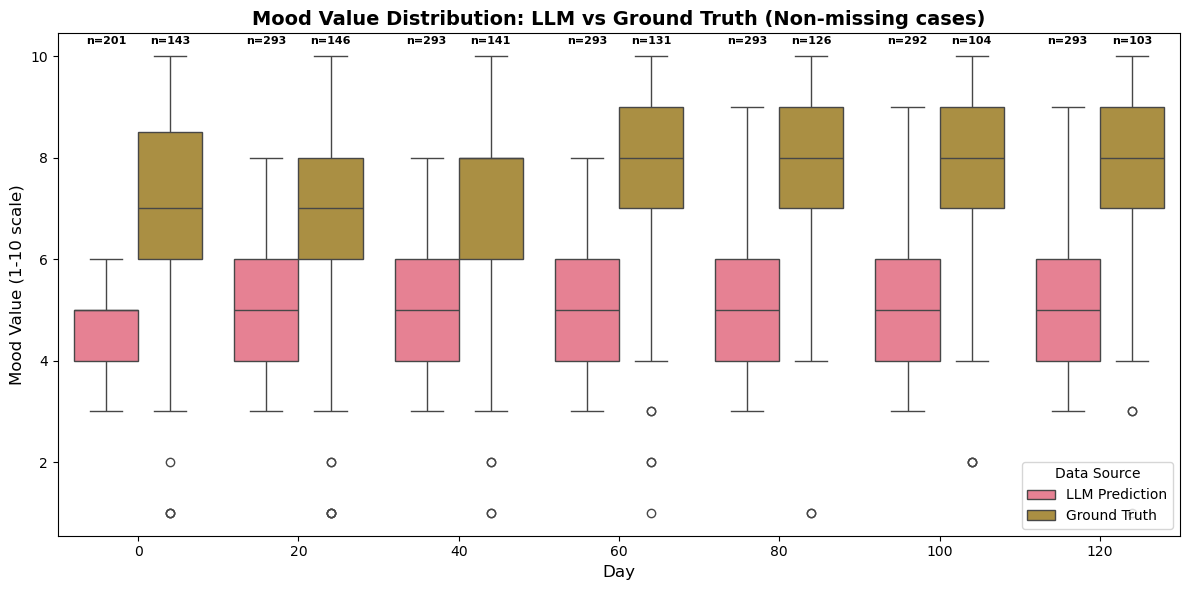


SUMMARY STATISTICS: Mood Values (Non-missing cases)

Day 0:
------------------------------
  LLM Prediction:
    Mean: 4.84 ± 0.78
    Median: 5.00
    Range: 3.0 - 6.0
    Sample size: 201
  Ground Truth:
    Mean: 7.18 ± 1.93
    Median: 7.00
    Range: 1.0 - 10.0
    Sample size: 143

Day 20:
------------------------------
  LLM Prediction:
    Mean: 4.93 ± 0.89
    Median: 5.00
    Range: 3.0 - 8.0
    Sample size: 293
  Ground Truth:
    Mean: 7.04 ± 2.07
    Median: 7.00
    Range: 1.0 - 10.0
    Sample size: 146

Day 40:
------------------------------
  LLM Prediction:
    Mean: 4.94 ± 0.91
    Median: 5.00
    Range: 3.0 - 8.0
    Sample size: 293
  Ground Truth:
    Mean: 7.28 ± 1.85
    Median: 8.00
    Range: 1.0 - 10.0
    Sample size: 141

Day 60:
------------------------------
  LLM Prediction:
    Mean: 4.95 ± 0.90
    Median: 5.00
    Range: 3.0 - 8.0
    Sample size: 293
  Ground Truth:
    Mean: 7.61 ± 1.80
    Median: 8.00
    Range: 1.0 - 10.0
    Sample size: 131


In [4]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
from typing import Dict, List, Tuple

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

def load_predictions(trajectory_dir: Path) -> Dict[str, List[Dict]]:
    """
    Load all predictions from traj_0 directory
    """
    predictions_data = {}
    
    for participant_dir in trajectory_dir.iterdir():
        if participant_dir.is_dir():
            participant_id = participant_dir.name
            predictions_file = participant_dir / "predictions.json"
            
            if predictions_file.exists():
                with open(predictions_file, 'r', encoding='utf-8') as f:
                    predictions_data[participant_id] = json.load(f)
    
    return predictions_data

def load_ground_truth() -> Dict[str, Dict]:
    """
    Load ground truth data from participants_data.json
    """
    with open("participants_data.json", 'r', encoding='utf-8') as f:
        return json.load(f)

def extract_mood_values(predictions_data: Dict[str, List[Dict]], 
                       ground_truth_data: Dict[str, Dict], 
                       target_days: List[int]) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Extract mood values for non-missing cases from LLM predictions and ground truth
    """
    llm_mood_data = []
    ground_truth_mood_data = []
    
    for participant_id, predictions in predictions_data.items():
        if participant_id not in ground_truth_data:
            continue
            
        # Get ground truth mood data
        gt_mood_data = ground_truth_data[participant_id].get("Mood", {})
        
        for day in target_days:
            # Find prediction for this day
            prediction = next((p for p in predictions if p.get("day") == day), None)
            
            if prediction and "model_response_parsed" in prediction:
                parsed = prediction["model_response_parsed"]
                
                # Skip if parsed is None
                if parsed is None:
                    continue
                    
                # Extract mood_score from LLM prediction
                mood_score = parsed.get("mood_score")
                
                # LLM prediction mood value (if not missing and valid number)
                if mood_score is not None and mood_score != "missing":
                    try:
                        mood_value = float(mood_score)
                        if 1 <= mood_value <= 10:  # Validate range
                            llm_mood_data.append({
                                'participant_id': participant_id,
                                'day': day,
                                'mood_value': mood_value,
                                'source': 'LLM Prediction'
                            })
                    except (ValueError, TypeError):
                        pass
                
                # Ground truth mood value (if not missing)
                day_key = f"Day {day}"
                if day_key in gt_mood_data:
                    try:
                        mood_value = float(gt_mood_data[day_key])
                        if 1 <= mood_value <= 10:  # Validate range
                            ground_truth_mood_data.append({
                                'participant_id': participant_id,
                                'day': day,
                                'mood_value': mood_value,
                                'source': 'Ground Truth'
                            })
                    except (ValueError, TypeError):
                        pass
    
    llm_df = pd.DataFrame(llm_mood_data)
    gt_df = pd.DataFrame(ground_truth_mood_data)
    
    return llm_df, gt_df

def plot_mood_value_comparison(llm_mood_df: pd.DataFrame, gt_mood_df: pd.DataFrame):
    """
    Plot comparison of mood values between LLM predictions and ground truth
    """
    # Combine data
    combined_mood_df = pd.concat([llm_mood_df, gt_mood_df], ignore_index=True)
    
    # Create plot
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Box plot by day and source
    sns.boxplot(data=combined_mood_df, x='day', y='mood_value', hue='source', ax=ax)
    ax.set_title('Mood Value Distribution: LLM vs Ground Truth (Non-missing cases)', 
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Day', fontsize=12)
    ax.set_ylabel('Mood Value (1-10 scale)', fontsize=12)
    ax.legend(title='Data Source')
    
    # Add sample size annotations
    for i, day in enumerate(sorted(combined_mood_df['day'].unique())):
        day_data = combined_mood_df[combined_mood_df['day'] == day]
        for j, source in enumerate(['LLM Prediction', 'Ground Truth']):
            source_data = day_data[day_data['source'] == source]
            if len(source_data) > 0:
                # Position the text above the box
                y_pos = combined_mood_df['mood_value'].max() + 0.2
                x_pos = i + (j * 0.4 - 0.2)  # Adjust position for each source
                ax.text(x_pos, y_pos, f'n={len(source_data)}', 
                       ha='center', va='bottom', fontsize=8, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    return combined_mood_df

# Main execution
print("Loading data...")
trajectory_dir = Path("traj_0")
predictions_data = load_predictions(trajectory_dir)
ground_truth_data = load_ground_truth()

print(f"Loaded predictions for {len(predictions_data)} participants")
print(f"Loaded ground truth for {len(ground_truth_data)} participants")

# Target days for analysis
target_days = [0, 20, 40, 60, 80, 100, 120]

print("\n" + "="*60)
print("ANALYSIS: Mood Value Comparison (Non-missing cases)")
print("="*60)

llm_mood_df, gt_mood_df = extract_mood_values(
    predictions_data, ground_truth_data, target_days
)

combined_mood_df = plot_mood_value_comparison(llm_mood_df, gt_mood_df)

# Print summary statistics
print("\n" + "="*60)
print("SUMMARY STATISTICS: Mood Values (Non-missing cases)")
print("="*60)

for day in target_days:
    print(f"\nDay {day}:")
    print("-" * 30)
    
    for source in ['LLM Prediction', 'Ground Truth']:
        day_source_data = combined_mood_df[
            (combined_mood_df['day'] == day) & 
            (combined_mood_df['source'] == source)
        ]
        if len(day_source_data) > 0:
            mean_val = day_source_data['mood_value'].mean()
            std_val = day_source_data['mood_value'].std()
            count_val = len(day_source_data)
            min_val = day_source_data['mood_value'].min()
            max_val = day_source_data['mood_value'].max()
            median_val = day_source_data['mood_value'].median()
            
            print(f"  {source}:")
            print(f"    Mean: {mean_val:.2f} ± {std_val:.2f}")
            print(f"    Median: {median_val:.2f}")
            print(f"    Range: {min_val:.1f} - {max_val:.1f}")
            print(f"    Sample size: {count_val}")
        else:
            print(f"  {source}: No data available")

# Overall statistics
print("\n" + "="*60)
print("OVERALL SUMMARY (All Days Combined)")
print("="*60)

for source in ['LLM Prediction', 'Ground Truth']:
    source_data = combined_mood_df[combined_mood_df['source'] == source]
    if len(source_data) > 0:
        mean_val = source_data['mood_value'].mean()
        std_val = source_data['mood_value'].std()
        count_val = len(source_data)
        min_val = source_data['mood_value'].min()
        max_val = source_data['mood_value'].max()
        median_val = source_data['mood_value'].median()
        
        print(f"\n{source}:")
        print(f"  Mean: {mean_val:.2f} ± {std_val:.2f}")
        print(f"  Median: {median_val:.2f}")
        print(f"  Range: {min_val:.1f} - {max_val:.1f}")
        print(f"  Total samples: {count_val}")
        
        # Distribution by mood value
        print(f"  Distribution:")
        for mood_val in range(1, 11):
            count = len(source_data[source_data['mood_value'] == mood_val])
            if count > 0:
                percentage = (count / count_val) * 100
                print(f"    {mood_val}: {count} ({percentage:.1f}%)")
    else:
        print(f"\n{source}: No data available")

# Additional analysis: Compare distributions statistically
print("\n" + "="*60)
print("STATISTICAL COMPARISON")
print("="*60)

from scipy import stats

llm_data = combined_mood_df[combined_mood_df['source'] == 'LLM Prediction']['mood_value']
gt_data = combined_mood_df[combined_mood_df['source'] == 'Ground Truth']['mood_value']

if len(llm_data) > 0 and len(gt_data) > 0:
    # T-test for difference in means
    t_stat, p_value = stats.ttest_ind(llm_data, gt_data, equal_var=False)
    print(f"T-test for difference in means:")
    print(f"  t-statistic: {t_stat:.3f}, p-value: {p_value:.3f}")
    
    # Mann-Whitney U test for difference in distributions
    u_stat, p_value_mw = stats.mannwhitneyu(llm_data, gt_data, alternative='two-sided')
    print(f"Mann-Whitney U test:")
    print(f"  U-statistic: {u_stat:.0f}, p-value: {p_value_mw:.3f}")
    
    # Effect size (Cohen's d)
    pooled_std = np.sqrt((llm_data.std()**2 + gt_data.std()**2) / 2)
    cohens_d = (llm_data.mean() - gt_data.mean()) / pooled_std
    print(f"Effect size (Cohen's d): {cohens_d:.3f}")
else:
    print("Insufficient data for statistical comparison")